In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
#  Defining Reservoir properties
L = 1.0          # Reservoir length
alpha = 0.1      # Pressure diffusivity

# Spatial grid
Nx = 101
x = np.linspace(0, L, Nx)

# Time grid
T_max = 1.0
dt = 0.00004
Nt = int(round(T_max / dt) + 1)

print("Number of spatial points:", Nx)
print("Number of time steps:", Nt)

Number of spatial points: 101
Number of time steps: 25001


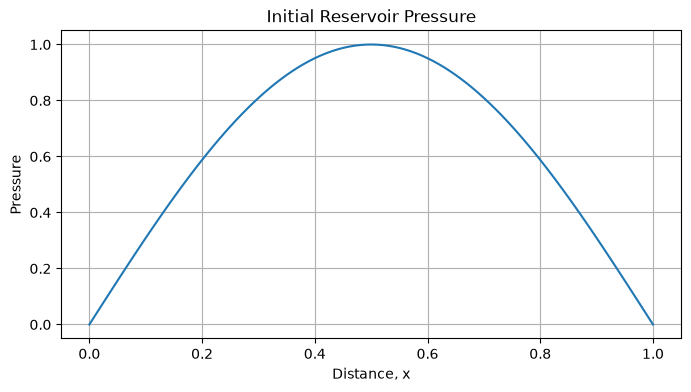

In [32]:
# Initial pressure distribution
p_initial = np.sin(np.pi * x)

# Plot the initial pressure
plt.figure(figsize=(8, 4))
plt.plot(x, p_initial)
plt.xlabel("Distance, x")
plt.ylabel("Pressure")
plt.title("Initial Reservoir Pressure")
plt.grid()
plt.savefig("../results/initial_pressure.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
# Creating the pressure array
pressure = np.zeros((Nt, Nx))

# Setting the initial pressure condition
pressure[0, :] = p_initial

print("Pressure array shape:", pressure.shape)

Pressure array shape: (25001, 101)


In [34]:
# Creating an empty array to store pressure over time and space
pressure = np.zeros((Nt, Nx))

# Inserting the initial pressure distribution
pressure[0, :] = p_initial

print("Pressure array shape:", pressure.shape)

Pressure array shape: (25001, 101)


In [35]:
# Inspecting the initial pressure values
print("Pressure at x = 0:", pressure[0, 0])
print("Pressure at x = 0.5:", pressure[0, Nx // 2])
print("pressure at x= 0.8:", pressure[0, int(0.8 * (Nx - 1))])
print("Pressure at x = 1:", pressure[0, -1])

Pressure at x = 0: 0.0
Pressure at x = 0.5: 1.0
pressure at x= 0.8: 0.5877852522924732
Pressure at x = 1: 1.2246467991473532e-16


In [36]:
# Spatial step
dx = x[1] - x[0]

# Stability parameter
r = alpha * dt / dx**2

print("Spatial step (dx):", dx)
print("Time step (dt):", dt)
print("Pressure diffusivity (alpha):", alpha)
print("Stability parameter (r):", r)
print("Stable:", r <= 0.5)

Spatial step (dx): 0.01
Time step (dt): 4e-05
Pressure diffusivity (alpha): 0.1
Stability parameter (r): 0.04000000000000001
Stable: True


In [38]:
# Numerical solution of the pressure-diffusion equation

for n in range(Nt - 1):

    # Update pressure at the interior grid points
    pressure[n + 1, 1:-1] = (
        pressure[n, 1:-1]
        + r * (
            pressure[n, 2:]
            - 2 * pressure[n, 1:-1]
            + pressure[n, :-2]
        )
    )

    # Boundary conditions
    pressure[n + 1, 0] = 0.0
    pressure[n + 1, -1] = 0.0

print("Numerical simulation complete.")

Numerical simulation complete.


In [39]:
# Check how pressure at the center changes with time

center_index = Nx // 2

print("Initial center pressure:", pressure[0, center_index])
print("Final center pressure:", pressure[-1, center_index])

Initial center pressure: 1.0
Final center pressure: 0.3727308328207824


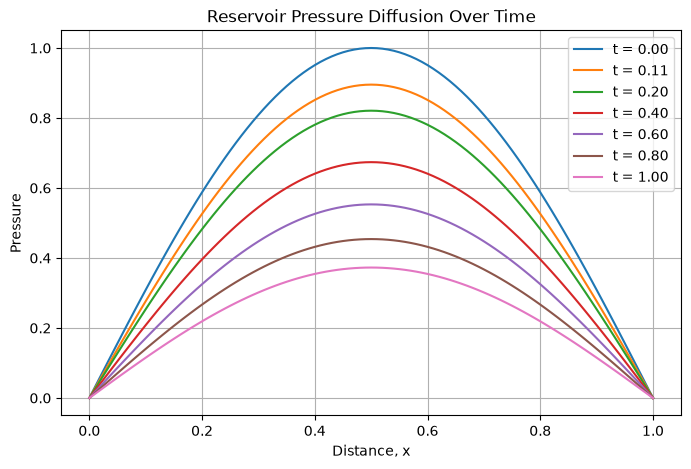

In [41]:
# Plotting pressure distribution at different times

time_indices = [0, 2800, 5000, 10000, 15000, 20000, 25000]

plt.figure(figsize=(8, 5))

for n in time_indices:
    plt.plot(x, pressure[n, :], label=f"t = {n * dt:.2f}")

plt.xlabel("Distance, x")
plt.ylabel("Pressure")
plt.title("Reservoir Pressure Diffusion Over Time")
plt.legend()
plt.grid()

plt.savefig("../results/pressure_diffusion.png", dpi=300, bbox_inches="tight")

plt.show()

In [43]:
# Test one pressure update manually

n = 0

pressure[1, 1:-1] = (
    pressure[0, 1:-1]
    + r * (
        pressure[0, 2:]
        - 2 * pressure[0, 1:-1]
        + pressure[0, :-2]
    )
)

# Apply boundary conditions
pressure[1, 0] = 0.0
pressure[1, -1] = 0.0

print("Center pressure at t = 0:", pressure[0, Nx // 2])
print("Center pressure after one step:", pressure[1, Nx // 2])

Center pressure at t = 0: 1.0
Center pressure after one step: 0.9999605248292586


In [44]:
# Run the full pressure-diffusion simulation

for n in range(Nt - 1):

    pressure[n + 1, 1:-1] = (
        pressure[n, 1:-1]
        + r * (
            pressure[n, 2:]
            - 2 * pressure[n, 1:-1]
            + pressure[n, :-2]
        )
    )

    # Apply boundary conditions
    pressure[n + 1, 0] = 0.0
    pressure[n + 1, -1] = 0.0

print("Simulation complete.")
print("Pressure array shape:", pressure.shape)

Simulation complete.
Pressure array shape: (25001, 101)


In [49]:
# ============================================================
# Create Reference Dataset
# ============================================================

# Create time array
time = np.arange(Nt) * dt

# Create a 2D grid of x and time
X, T = np.meshgrid(x, time)

# Convert everything into one-dimensional columns
x_data = X.flatten()
time_data = T.flatten()
pressure_data = pressure.flatten()

# Create the dataset
reference_data = pd.DataFrame({
    "x": x_data,
    "time": time_data,
    "pressure": pressure_data
})

# Save the dataset
reference_data.to_csv("../data/reference_pressure_1d.csv", index=False)

print("Reference dataset created.")
print("Dataset shape:", reference_data.shape)
print(reference_data.head())

Reference dataset created.
Dataset shape: (2525101, 3)
      x  time  pressure
0  0.00   0.0  0.000000
1  0.01   0.0  0.031411
2  0.02   0.0  0.062791
3  0.03   0.0  0.094108
4  0.04   0.0  0.125333


In [50]:
# ============================================================
# Validate Reference Dataset
# ============================================================

print("Number of rows:", len(reference_data))
print("Number of columns:", len(reference_data.columns))

print("\nMissing values:")
print(reference_data.isnull().sum())

print("\nTime range:")
print(reference_data["time"].min(), "to", reference_data["time"].max())

print("\nSpatial range:")
print(reference_data["x"].min(), "to", reference_data["x"].max())

print("\nPressure range:")
print(reference_data["pressure"].min(), "to", reference_data["pressure"].max())

Number of rows: 2525101
Number of columns: 3

Missing values:
x           0
time        0
pressure    0
dtype: int64

Time range:
0.0 to 1.0

Spatial range:
0.0 to 1.0

Pressure range:
0.0 to 1.0


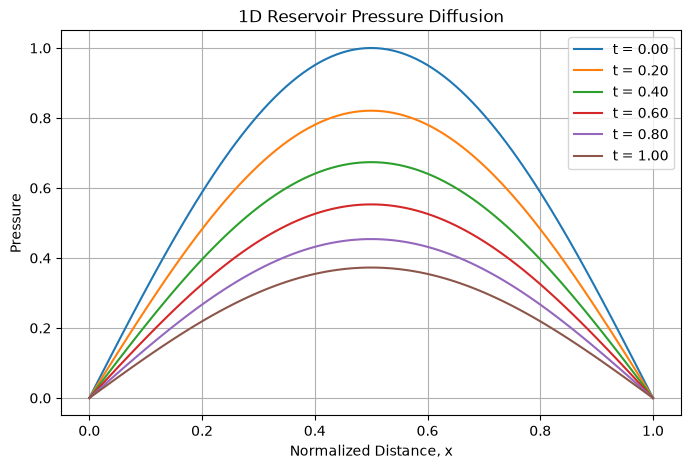

In [51]:
# ============================================================
# Visualize Reference Dataset
# ============================================================

times_to_plot = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

plt.figure(figsize=(8, 5))

for t in times_to_plot:
    # Find the time index closest to the requested time
    time_index = np.argmin(np.abs(time - t))

    plt.plot(
        x,
        pressure[time_index, :],
        label=f"t = {time[time_index]:.2f}"
    )

plt.xlabel("Normalized Distance, x")
plt.ylabel("Pressure")
plt.title("1D Reservoir Pressure Diffusion")
plt.legend()
plt.grid()

plt.savefig(
    "../results/reference_pressure_diffusion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()